# Part 1: Creating and Manipulating Arrays

In [23]:
import numpy as np
import matplotlib.pyplot as plt

1.1. Create two 2D arrays representing coordinates x, y on the cartesian plan

In [2]:
# 100 points from -2 to 2 inclusive
x1d = np.linspace(-2, 2, 100)
y1d = np.linspace(-2, 2, 100)

# Make 2D coordinate grids
x, y = np.meshgrid(x1d, y1d)

x.shape, y.shape

((100, 100), (100, 100))

1.2. Visualize each 2D array using pcolormesh

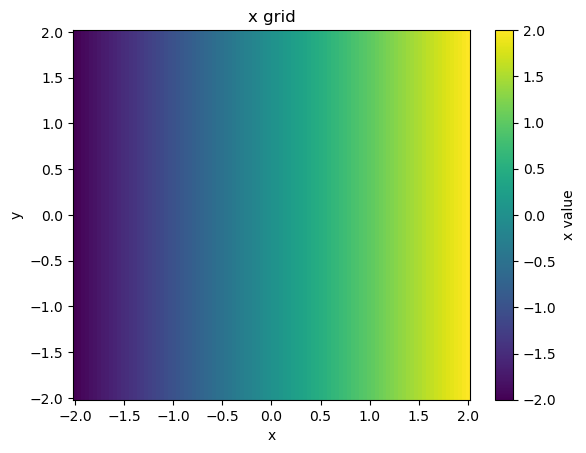

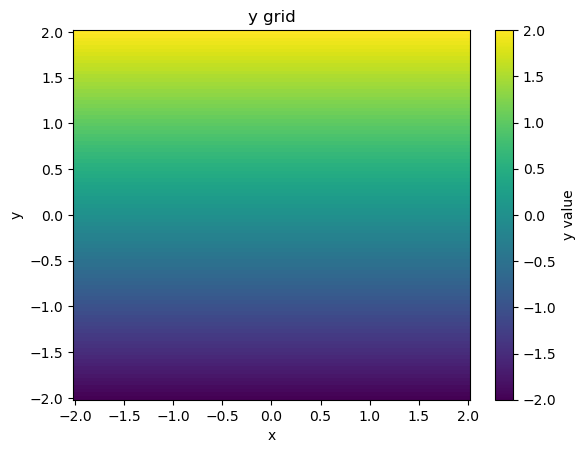

In [3]:
plt.figure()
plt.pcolormesh(x1d, y1d, x, shading="auto")
plt.colorbar(label="x value")
plt.title("x grid")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

plt.figure()
plt.pcolormesh(x1d, y1d, y, shading="auto")
plt.colorbar(label="y value")
plt.title("y grid")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

1.3 From your cartesian coordinates, create polar coordinates r and φ

In [4]:
r = np.sqrt(x**2 + y**2)
phi = np.arctan2(y, x)

r.shape, phi.shape

((100, 100), (100, 100))

1.4 Visualize r and φ on the 2D plane with pcolormesh

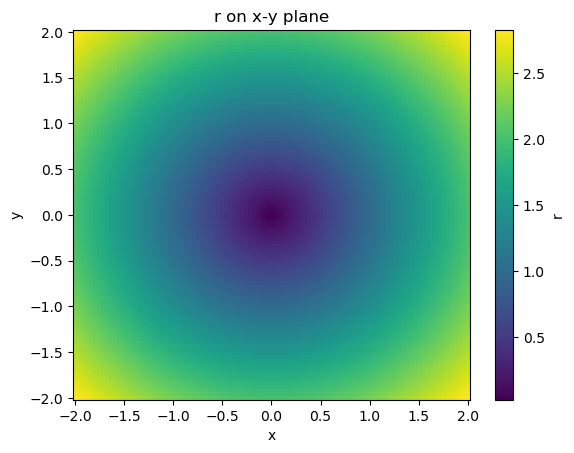

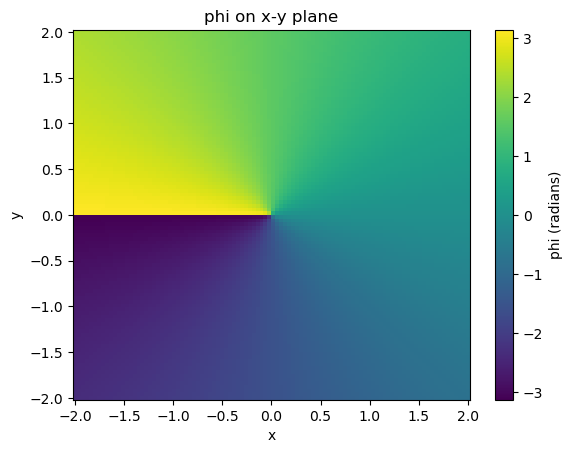

In [5]:
plt.figure()
plt.pcolormesh(x1d, y1d, r, shading="auto")
plt.colorbar(label="r")
plt.title("r on x-y plane")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

plt.figure()
plt.pcolormesh(x1d, y1d, phi, shading="auto")
plt.colorbar(label="phi (radians)")
plt.title("phi on x-y plane")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

1.5 Caclulate the quanity f = cos²(4r) + sin²(4φ) and plot on x-y plane

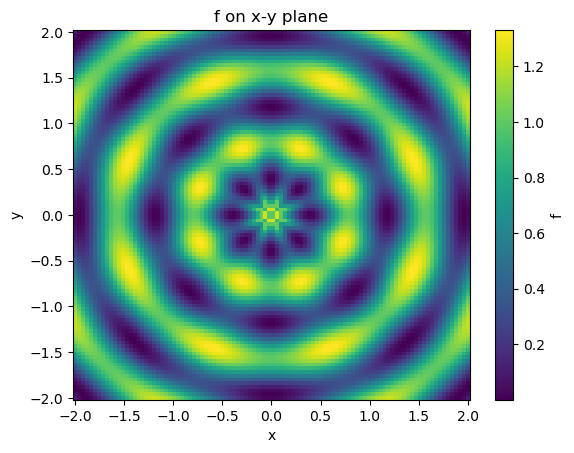

In [6]:
f = np.cos(4*r)**2 + (np.sin(4*phi)**2)/3

plt.figure()
plt.pcolormesh(x1d, y1d, f, shading="auto")
plt.colorbar(label="f")
plt.title("f on x-y plane")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

# Part 2: Analyze ARGO Data

In [11]:
import pooch
url = "https://www.ldeo.columbia.edu/~danielmw/float_data.zip"
files = pooch.retrieve(url, processor=pooch.Unzip(), known_hash="2a703c720302c682f1662181d329c9f22f9f10e1539dc2d6082160a469165009")
files

Unzipping contents of '/home/yk3149/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip' to '/home/yk3149/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip'


['/home/yk3149/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/date.npy',
 '/home/yk3149/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/T.npy',
 '/home/yk3149/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/S.npy',
 '/home/yk3149/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/P.npy',
 '/home/yk3149/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/levels.npy',
 '/home/yk3149/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/lon.npy',
 '/home/yk3149/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/lat.npy']

2.1 Load each data file as a numpy array

In [13]:
import os

# Convert list to dict by filename
file_map = {os.path.basename(f).lower(): f for f in files}
file_map.keys()

dict_keys(['date.npy', 't.npy', 's.npy', 'p.npy', 'levels.npy', 'lon.npy', 'lat.npy'])

In [15]:
date   = np.load(file_map["date.npy"])
T      = np.load(file_map["t.npy"])
S      = np.load(file_map["s.npy"])
P      = np.load(file_map["p.npy"])
level  = np.load(file_map["levels.npy"])
lon    = np.load(file_map["lon.npy"])
lat    = np.load(file_map["lat.npy"])

# Check shapes
print("T:", T.shape)
print("S:", S.shape)
print("P:", P.shape)
print("level:", level.shape)
print("lon:", lon.shape)
print("lat:", lat.shape)
print("date:", date.shape)

T: (78, 75)
S: (78, 75)
P: (78, 75)
level: (78,)
lon: (75,)
lat: (75,)
date: (75,)


2.2 Examine the shapes of T, S and P compared to lon, lat, date and level. How do you think they are related?

T, S, and P are 2D arrays of shape (78, 75). The 78 matches level (78 depth levels), and the 75 matches lon, lat, and date (75 profiles). Therefore the rows correspond to depth and the columns correspond to profiles, and T/S/P share both dimensions.

2.3 Make a plot for each column of data in T, S and P (three plots).

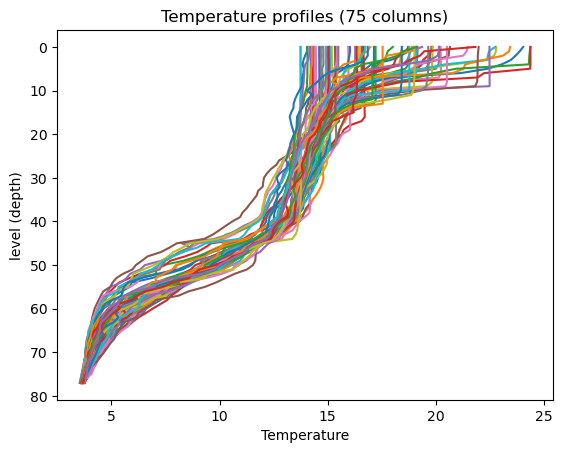

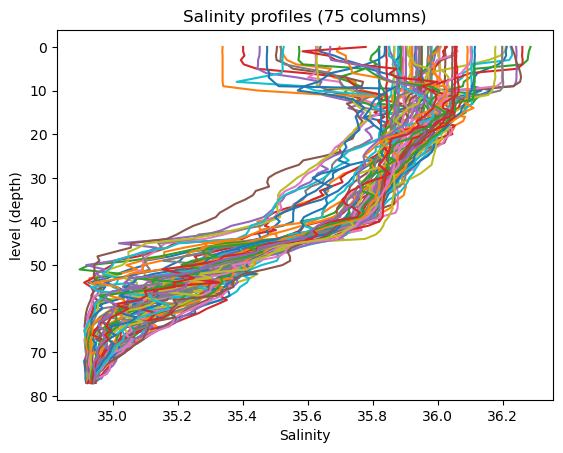

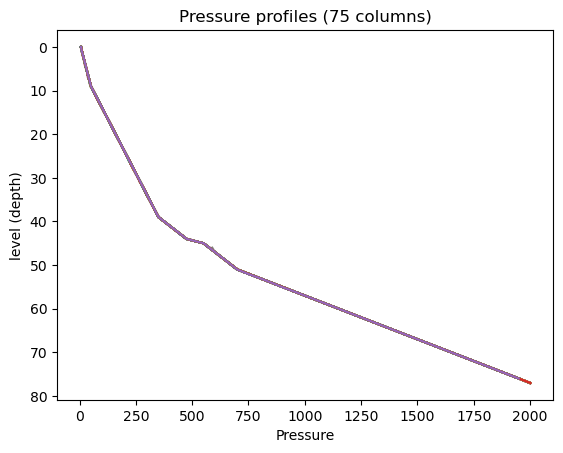

In [16]:
import matplotlib.pyplot as plt

def messy_profile_plot(A, level, title, xlabel):
    plt.figure()
    for j in range(A.shape[1]):      # 75 profiles
        plt.plot(A[:, j], level)     # depth on y-axis
    plt.gca().invert_yaxis()
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("level (depth)")
    plt.show()

messy_profile_plot(T, level, "Temperature profiles (75 columns)", "Temperature")
messy_profile_plot(S, level, "Salinity profiles (75 columns)", "Salinity")
messy_profile_plot(P, level, "Pressure profiles (75 columns)", "Pressure")

2.4 Compute the mean and standard deviation of each of T, S and P at each depth in level.

In [17]:
T_mean = np.mean(T, axis=1)
T_std  = np.std(T, axis=1)

S_mean = np.mean(S, axis=1)
S_std  = np.std(S, axis=1)

P_mean = np.mean(P, axis=1)
P_std  = np.std(P, axis=1)

print(T_mean.shape, T_std.shape)  # (78,) (78,)
print(S_mean.shape, S_std.shape)  # (78,) (78,)
print(P_mean.shape, P_std.shape)  # (78,) (78,)

(78,) (78,)
(78,) (78,)
(78,) (78,)


2.5 Now make three similar plot, but show only the mean T, S and P at each depth. Show error bars on each plot using the standard deviations.

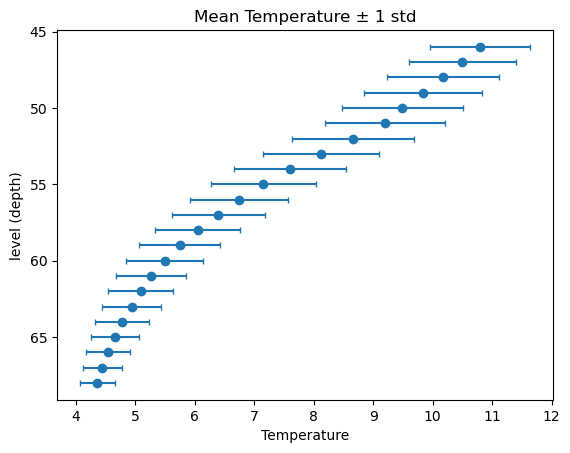

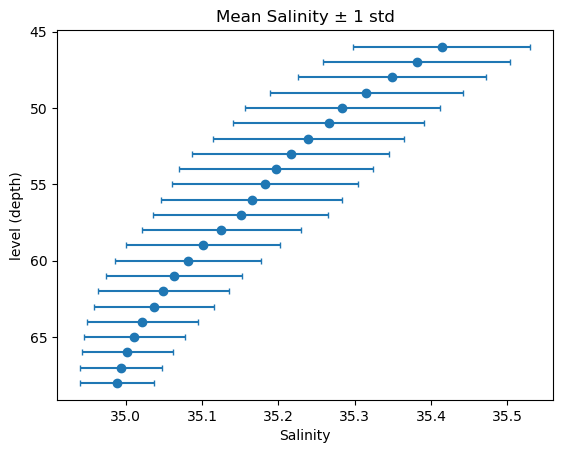

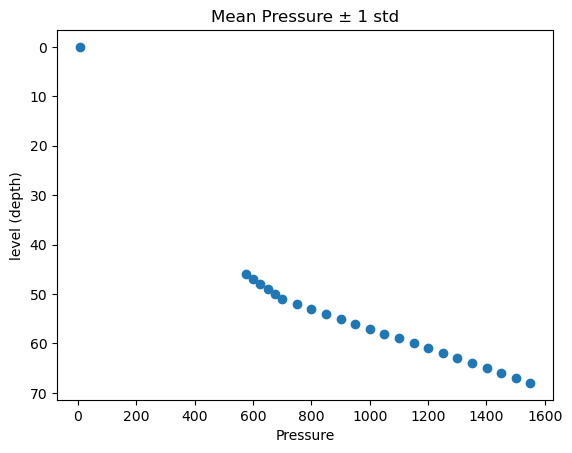

In [18]:
def mean_error_plot(mean, std, level, title, xlabel):
    plt.figure()
    plt.errorbar(mean, level, xerr=std, fmt="o", capsize=2)
    plt.gca().invert_yaxis()
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("level (depth)")
    plt.show()

mean_error_plot(T_mean, T_std, level, "Mean Temperature ± 1 std", "Temperature")
mean_error_plot(S_mean, S_std, level, "Mean Salinity ± 1 std", "Salinity")
mean_error_plot(P_mean, P_std, level, "Mean Pressure ± 1 std", "Pressure")

2.6 Account For Missing Data

(78,) (78,)


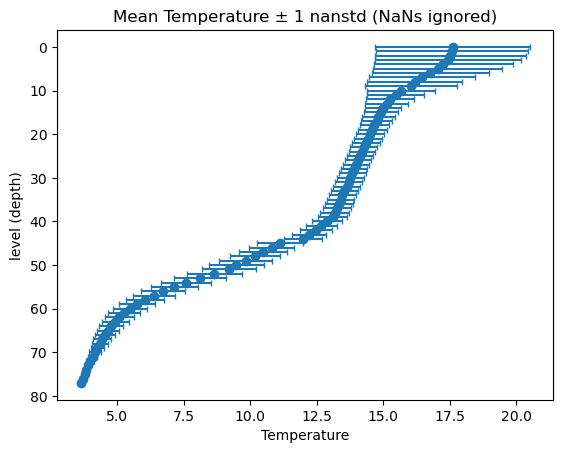

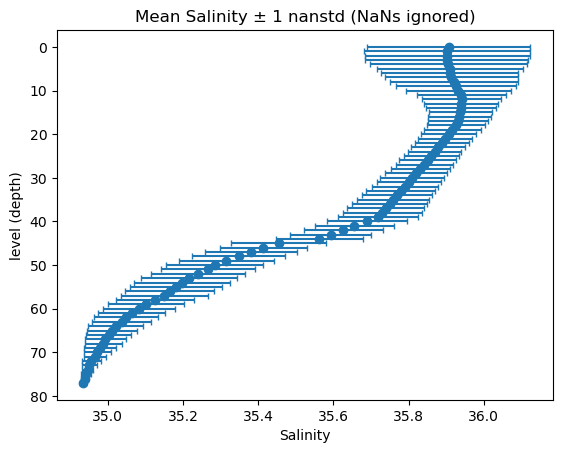

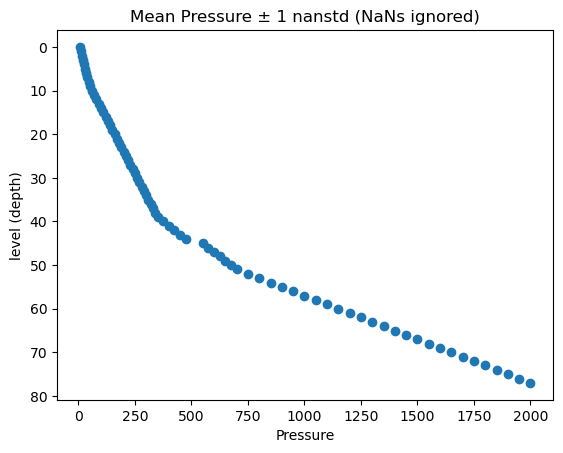

In [20]:
T_mean_n = np.nanmean(T, axis=1)
T_std_n  = np.nanstd(T, axis=1)

S_mean_n = np.nanmean(S, axis=1)
S_std_n  = np.nanstd(S, axis=1)

P_mean_n = np.nanmean(P, axis=1)
P_std_n  = np.nanstd(P, axis=1)

print(T_mean_n.shape, T_std_n.shape)  # (78,) (78,) etc.

mean_error_plot(T_mean_n, T_std_n, level, "Mean Temperature ± 1 nanstd (NaNs ignored)", "Temperature")
mean_error_plot(S_mean_n, S_std_n, level, "Mean Salinity ± 1 nanstd (NaNs ignored)", "Salinity")
mean_error_plot(P_mean_n, P_std_n, level, "Mean Pressure ± 1 nanstd (NaNs ignored)", "Pressure")

2.7 Create a scatter plot of the lon, lat positions of the ARGO float.

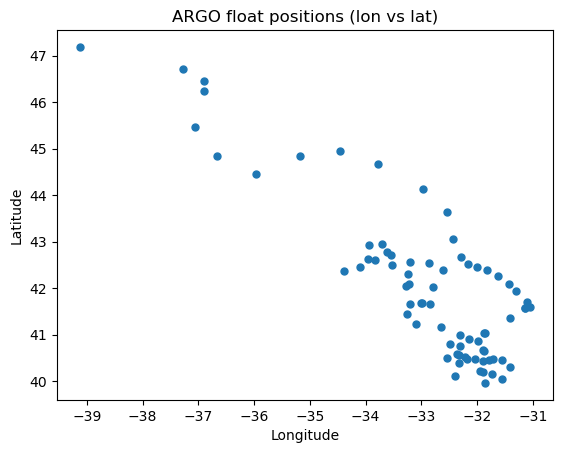

In [22]:
plt.figure()
plt.scatter(lon, lat, s=25)
plt.title("ARGO float positions (lon vs lat)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()